# Bifrost.jl — visual demos

One notebook consolidating every visual demo that historically lived in
`test/human/demo*.jl`. Each section tells one story about the Bifrost API: the cells
exercising Bifrost are written to be read (duplication is deliberate), and all plotting
machinery lives in [`demo-helper.jl`](demo-helper.jl). The narrative for each demo —
its lesson, edge case, or invariant — is recorded in [`demo-intent.md`](demo-intent.md).

**Running**: use any Julia 1.11 kernel; the setup cell activates the
`test/human` environment (`Project.toml` next to this notebook) and brings in the
helper. Plots are interactive Plotly figures rendered inline.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

using Bifrost
include("demo-helper.jl")
using .DemoHelper

## 1 · Path geometry

The geometry layer (`geometry/path-geometry.jl`) builds and queries three-dimensional
paths with no optics attached. Authoring follows one lifecycle on a `SubpathBuilder`:
`start!` → segment calls (`straight!`, `bend!`, `helix!`, `catenary!`, `jumpby!`) →
seal (`jumpto!` to a global target, or `seal!` at the natural exit) → `build`.

Every demo in this section renders through the **path inspector**
(`path_inspector` in `demo-helper.jl`): the centerline with arc-length-graded
markers, open circles at segment joins, green start / red end dots, and `Nickname`
labels. The **slider scrubs arc length** along the path, carrying a translucent
normal–binormal plane, the local T̂/N̂/B̂ frame triad (orange/blue/green), and a red
in-plane arrow at the accumulated spin phase; the readout below the scene reports
s; x, y, z; curvature κ; geometric torsion τ_geom; spin rate τ_spin; and ∫τ_spin ds.

### 1.1 · A simple multi-segment Subpath

All four curve primitives composed in one Subpath — straight · 90° bend · straight ·
catenary sag · 60° bend · straight — sealed at its natural exit. The lesson: segments
join with tangent (G1) continuity automatically, and the built path answers scalar
geometry queries (`path_length`, `writhe` — zero here, the path is planar).

Arc length: 0.5413716694115406 m
Writhe:     0.0


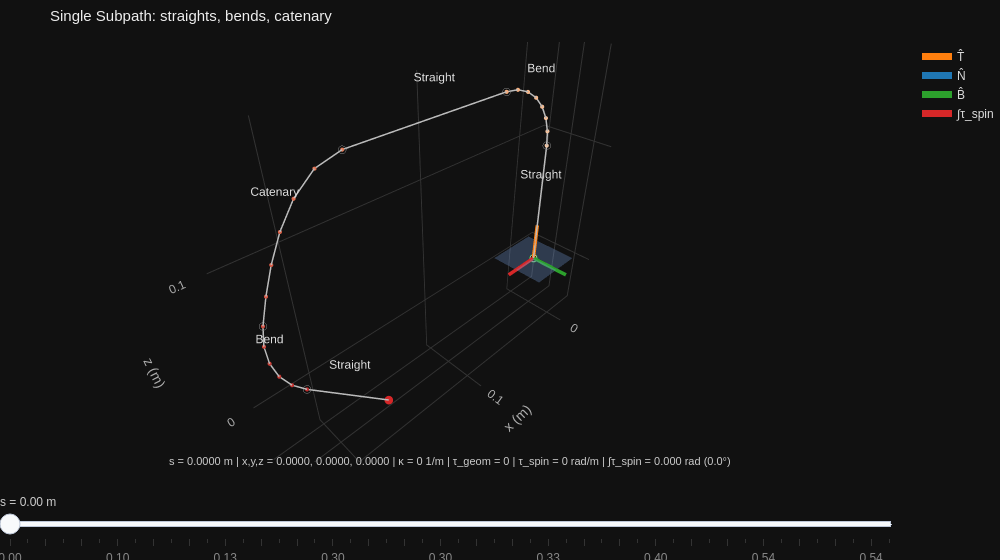

In [2]:
sb = SubpathBuilder(); start!(sb)
straight!(sb; length = 0.10, meta = [Nickname("Straight")])
bend!(sb;     radius = 0.05, angle = π / 2, meta = [Nickname("Bend")])
straight!(sb; length = 0.12, meta = [Nickname("Straight")])
catenary!(sb; a = 0.03, length = 0.10, axis_angle = 0.0, meta = [Nickname("Catenary")])
bend!(sb;     radius = 0.06, angle = π / 3, meta = [Nickname("Bend")])
straight!(sb; length = 0.08, meta = [Nickname("Straight")])
seal!(sb)
path = build(sb)

println("Arc length: ", path_length(path), " m")
println("Writhe:     ", writhe(path; n = 128))
path_inspector(path; title = "Single Subpath: straights, bends, catenary")

### 1.2 · Segment nicknames

The same spirit with a helix added, and every segment authored with a *descriptive*
`Nickname` (`lead-in`, `sag`, `spin section`, …). The lesson: names live with the
segment definition and flow through the build to presentation — nothing derives
labels from type information at render time.

Arc length: 0.5636008251177191 m


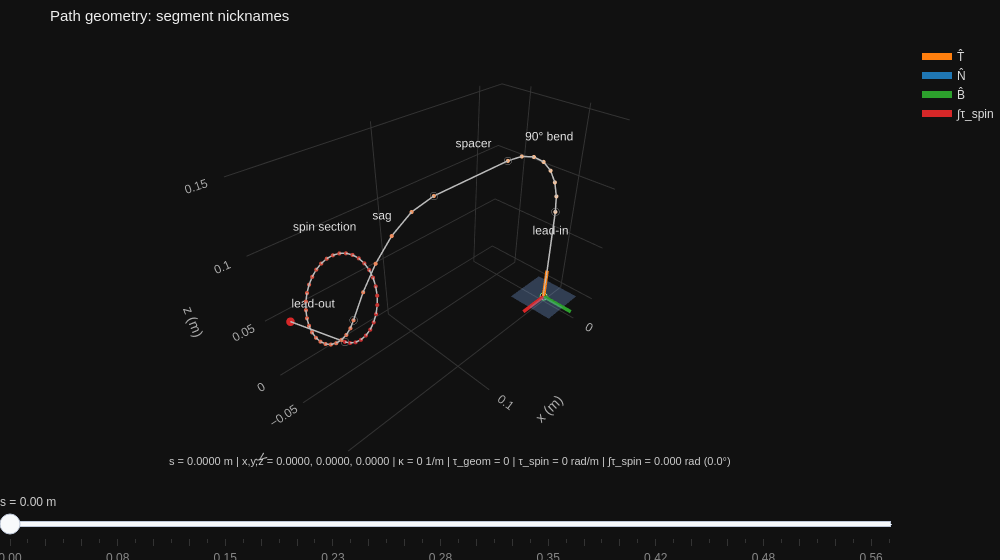

In [3]:
sb = SubpathBuilder(); start!(sb)
straight!(sb; length = 0.08, meta = [Nickname("lead-in")])
bend!(sb;     radius = 0.06, angle = π / 2, meta = [Nickname("90° bend")])
straight!(sb; length = 0.06, meta = [Nickname("spacer")])
catenary!(sb; a = 0.04, length = 0.08, axis_angle = 0.0, meta = [Nickname("sag")])
helix!(sb;    radius = 0.025, pitch = 0.015, turns = 1.2, axis_angle = 0.0,
              meta = [Nickname("spin section")])
straight!(sb; length = 0.06, meta = [Nickname("lead-out")])
seal!(sb)
path = build(sb)

println("Arc length: ", path_length(path), " m")
path_inspector(path; title = "Path geometry: segment nicknames")

### 1.3 · Helix `axis_angle`

A 2-turn helix between two straights, with `axis_angle` ∈ {0, π/3, 2π/3}.
`axis_angle` rotates the helix axis about the incoming tangent: entry stays
tangent-continuous for every value, while the exit direction — and where the
lead-out straight goes — swings around. The arc length is invariant under the
rotation, as the printout confirms.

*(The legacy demos rendered these as three separate files; here the comparison row
makes the lesson visible at a glance, and the inspector below it lets you scrub the
most out-of-plane variant in detail.)*

axis_angle = 0.0:  arc length = 0.4791 m
axis_angle = 1.0472:  arc length = 0.4791 m
axis_angle = 2.0944:  arc length = 0.4791 m


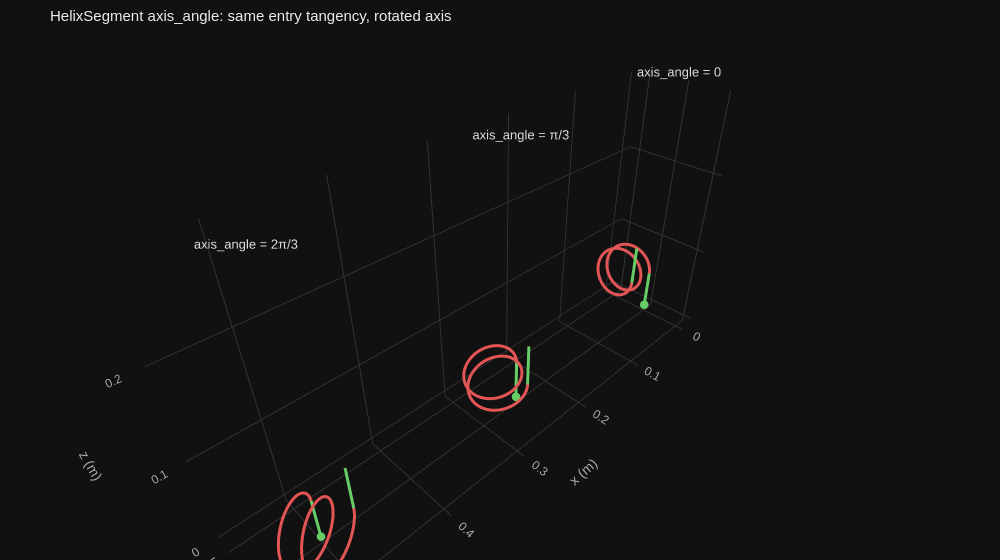

In [4]:
function helix_path(axis_angle)
    sb = SubpathBuilder(); start!(sb)
    straight!(sb; length = 0.05, meta = [Nickname("lead-in")])
    helix!(sb;    radius = 0.03, pitch = 0.02, turns = 2.0, axis_angle = axis_angle,
                  meta = [Nickname("helix")])
    straight!(sb; length = 0.05, meta = [Nickname("lead-out")])
    seal!(sb)
    return build(sb)
end

for aa in (0.0, π / 3, 2π / 3)
    println("axis_angle = ", round(aa; digits = 4),
            ":  arc length = ", round(path_length(helix_path(aa)); digits = 4), " m")
end

variant_row([("axis_angle = 0",    helix_path(0.0),    [2]),
             ("axis_angle = π/3",  helix_path(π / 3),  [2]),
             ("axis_angle = 2π/3", helix_path(2π / 3), [2])];
            spacing = 0.25,
            title = "HelixSegment axis_angle: same entry tangency, rotated axis")

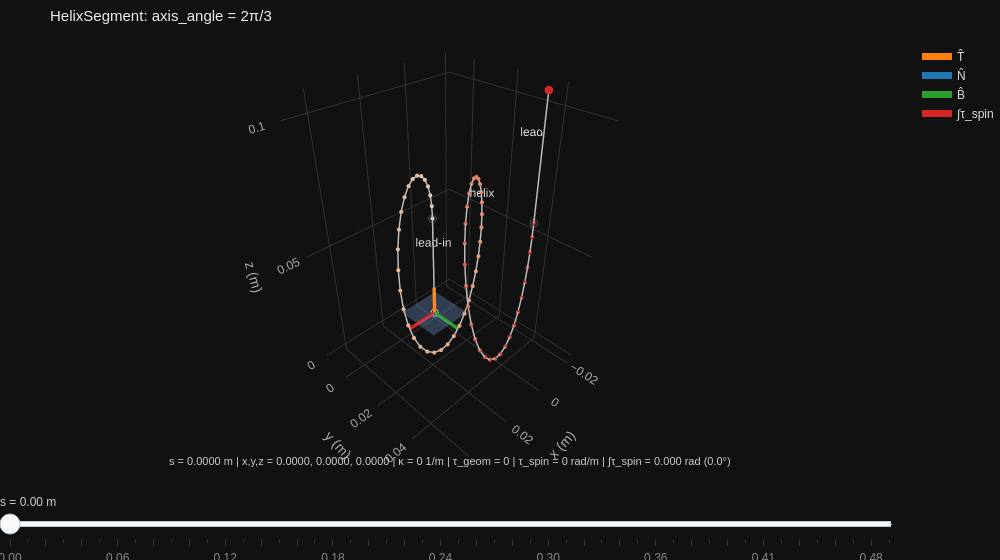

In [5]:
path_inspector(helix_path(2π / 3); title = "HelixSegment: axis_angle = 2π/3")

### 1.4 · The paddle: five Subpaths, `:inherit`, and `min_bend_radius`

A `PathBuilt` of five Subpaths forming a paddle pattern: vertical 1 m straights at
x = 0, 1, 2, 3 alternating up/down, joined by terminal `jumpto!` connectors with
anti-parallel landing tangents (180° U-turns), each with its own `min_bend_radius`.
Subpath 4 also carries an *interior* `jumpby!` — its `delta` is expressed in the
local frame (after heading −z, local (−1, 0, 0) lands at the global (2, 0, 0)) —
before its sealing `jumpto!`. Subpaths 2–5 start with `start!(sb, :inherit)`, so
each start state flows from the previous subpath's endpoint instead of being
hand-loaded.

PathBuilt arc length: 10.809918029675078 m


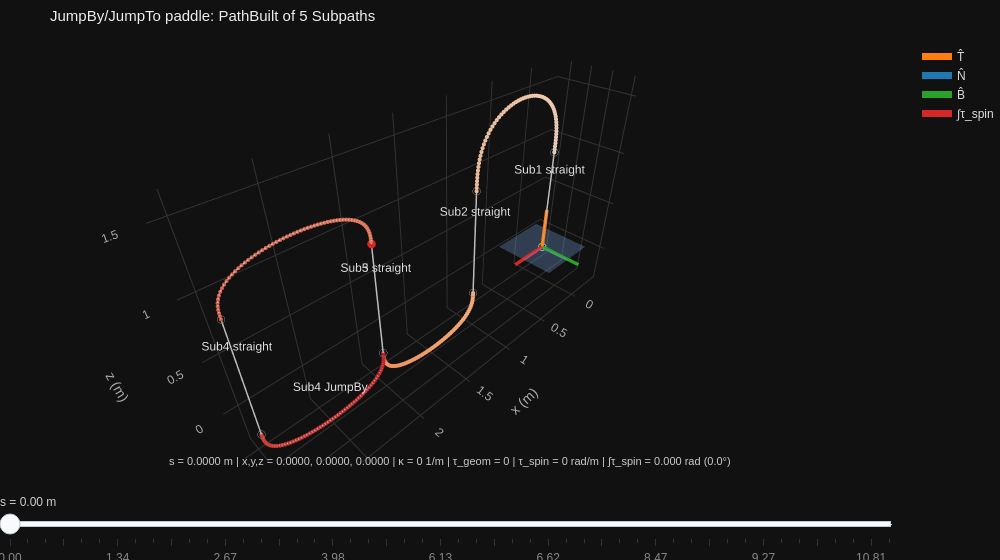

In [6]:
# Subpath 1: straight up to (0,0,1); U-turn connector lands at (1,0,1) heading -z.
sb1 = SubpathBuilder(); start!(sb1)
straight!(sb1; length = 1.0, meta = [Nickname("Sub1 straight")])
jumpto!(sb1; point = (1.0, 0.0, 1.0), incoming_tangent = (0.0, 0.0, -1.0),
        min_bend_radius = 0.4)

# Subpath 2: inherits (1,0,1) heading -z; straight down; U-turn to (2,0,0) heading +z.
sb2 = SubpathBuilder(); start!(sb2, :inherit)
straight!(sb2; length = 1.0, meta = [Nickname("Sub2 straight")])
jumpto!(sb2; point = (2.0, 0.0, 0.0), incoming_tangent = (0.0, 0.0, 1.0),
        min_bend_radius = 0.1)

# Subpath 3: inherits (2,0,0) heading +z; straight up; U-turn to (3,0,1) heading -z.
sb3 = SubpathBuilder(); start!(sb3, :inherit)
straight!(sb3; length = 1.0, meta = [Nickname("Sub3 straight")])
jumpto!(sb3; point = (3.0, 0.0, 1.0), incoming_tangent = (0.0, 0.0, -1.0),
        min_bend_radius = 0.05)

# Subpath 4: inherits (3,0,1) heading -z; straight down, then an INTERIOR JumpBy
# whose local-frame delta (-1,0,0) lands at the global (2,0,0) heading +z; the
# sealing jumpto! pins that landing point exactly.
sb4 = SubpathBuilder(); start!(sb4, :inherit)
straight!(sb4; length = 1.0, meta = [Nickname("Sub4 straight")])
jumpby!(sb4; delta = (-1.0, 0.0, 0.0), tangent = (0.0, 0.0, -1.0),
        min_bend_radius = 0.1, meta = [Nickname("Sub4 JumpBy")])
jumpto!(sb4; point = (2.0, 0.0, 0.0), incoming_tangent = (0.0, 0.0, 1.0))

# Subpath 5: inherits (2,0,0) heading +z and runs straight out.
sb5 = SubpathBuilder(); start!(sb5, :inherit)
straight!(sb5; length = 1.0, meta = [Nickname("Sub5 straight")])
seal!(sb5)

paddle = build([sb1, sb2, sb3, sb4, sb5])
println("PathBuilt arc length: ", path_length(paddle), " m")
path_inspector(paddle; fidelity = 4.0,
               title = "JumpBy/JumpTo paddle: PathBuilt of 5 Subpaths")

### 1.5 · PathBuilt assembly with exact handoffs

Three Subpaths — a straight sealed by `jumpto!` at (0, 0, 0.2), an `:inherit`
quarter-bend sealed by `jumpto!` at its analytic exit (R, 0, 0.2 + R), and an
`:inherit` helix sealed with `seal!` at its natural exit. A `jumpto!` seal pins
exact handoff coordinates, and the build's conformity check validates every
boundary. Per-Subpath `Nickname` meta labels whole subpaths.

Subpaths:   3
Arc length: 0.5160626204112496 m


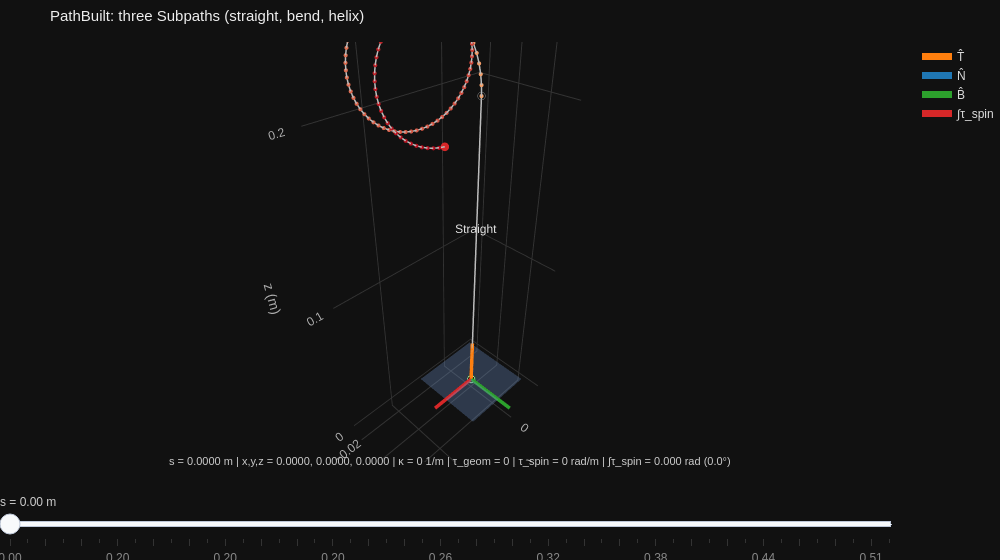

In [7]:
sb1 = SubpathBuilder(meta = [Nickname("Subpath 1: straight")])
start!(sb1)
straight!(sb1; length = 0.2, meta = [Nickname("Straight")])
jumpto!(sb1; point = (0.0, 0.0, 0.2), incoming_tangent = (0.0, 0.0, 1.0))

# Quarter bend from +z to +x: exits at (R, 0, 0.2 + R) heading +x.
R = 0.05
sb2 = SubpathBuilder(meta = [Nickname("Subpath 2: bend")])
start!(sb2, :inherit)
bend!(sb2; radius = R, angle = π / 2, meta = [Nickname("90° bend")])
jumpto!(sb2; point = (R, 0.0, 0.2 + R), incoming_tangent = (1.0, 0.0, 0.0))

sb3 = SubpathBuilder(meta = [Nickname("Subpath 3: helix")])
start!(sb3, :inherit)
helix!(sb3; radius = 0.025, pitch = 0.02, turns = 1.5, axis_angle = 0.0,
       meta = [Nickname("Helix")])
seal!(sb3)

path = build([sb1, sb2, sb3])
println("Subpaths:   ", length(path.subpaths))
println("Arc length: ", path_length(path), " m")
path_inspector(path; fidelity = 2.0,
               title = "PathBuilt: three Subpaths (straight, bend, helix)")